# 🔍 Task 1: Deteksi Fraud Transaksi Online
## End-to-End Deep Learning Pipeline

---

**Nama**: Rahmanda Afebrio Yuris Soesatyo   
**NIM**: 1103223024

---

### Deskripsi
Notebook ini membangun pipeline end-to-end untuk mendeteksi transaksi online yang berpotensi fraudulent. 
Menggunakan dataset `train_transaction.csv`, pipeline mencakup:
1. Eksplorasi dan Analisis Data (EDA)
2. Preprocessing & Feature Engineering
3. Penanganan Class Imbalance
4. Pembangunan Model Deep Learning (MLP)
5. Hyperparameter Tuning dengan **Optuna**
6. Evaluasi Model
7. Tracking Eksperimen dengan **MLFlow**

## 📦 0. Instalasi Library

Jalankan cell ini sekali untuk menginstall semua dependensi yang diperlukan.

In [ ]:
# Install library yang diperlukan
%pip install optuna mlflow imbalanced-learn tensorflow scikit-learn pandas numpy matplotlib seaborn -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
streamlit 1.41.0 requires protobuf<6,>=3.20, but you have protobuf 6.33.6 which is incompatible.
tensorflow-intel 2.18.0 requires ml-dtypes<0.5.0,>=0.4.0, but you have ml-dtypes 0.5.4 which is incompatible.
tensorflow-intel 2.18.0 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.3, but you have protobuf 6.33.6 which is incompatible.

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 📚 1. Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, ConfusionMatrixDisplay
)

# Class Imbalance
from imblearn.over_sampling import SMOTE

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# Hyperparameter Tuning
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

# MLFlow Tracking
import mlflow
import mlflow.keras

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

print('✅ Semua library berhasil diimport!')
print(f'TensorFlow version: {tf.__version__}')
print(f'Optuna version: {optuna.__version__}')
print(f'MLFlow version: {mlflow.__version__}')

c:\Users\62812\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Semua library berhasil diimport!
TensorFlow version: 2.21.0
Optuna version: 4.9.0
MLFlow version: 3.14.0


## 📂 2. Load Dataset

Pastikan file `train_transaction.csv` sudah ada di folder `Task1_FraudDetection/`.

In [3]:
# =====================================================
# KONFIGURASI PATH DATASET
# Ubah path di bawah jika file berada di lokasi lain
# =====================================================
DATASET_PATH = 'train_transaction.csv'

# Load dataset
print('⏳ Memuat dataset...')
df = pd.read_csv(DATASET_PATH)

print(f'✅ Dataset berhasil dimuat!')
print(f'   Jumlah baris   : {df.shape[0]:,}')
print(f'   Jumlah kolom   : {df.shape[1]:,}')
print(f'   Ukuran memori  : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')

⏳ Memuat dataset...
✅ Dataset berhasil dimuat!
   Jumlah baris   : 590,540
   Jumlah kolom   : 394
   Ukuran memori  : 2062.1 MB


## 🔍 3. Eksplorasi Data (EDA)

In [4]:
# Tampilkan 5 baris pertama
print('=== Preview Dataset ===')
df.head()

=== Preview Dataset ===


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# Informasi tipe data dan nilai non-null
print('=== Informasi Dataset ===')
print(df.info())

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), object(14)
memory usage: 1.7+ GB
None


In [6]:
# Statistik deskriptif
print('=== Statistik Deskriptif ===')
df.describe()

=== Statistik Deskriptif ===


,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000,524834.000000,524834.000000,...,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.00000,82351.000000,82351.000000,82351.000000,82351.000000
mean,3.282270e+06,0.034990,7.372311e+06,135.027176,9898.734658,362.555488,153.194925,199.278897,290.733794,86.800630,...,0.775874,721.741883,1375.783644,1014.622782,9.807015,59.16455,28.530903,55.352422,151.160542,100.700882
std,1.704744e+05,0.183755,4.617224e+06,239.162522,4901.170153,157.793246,11.336444,41.244453,101.741072,2.690623,...,4.727971,6217.223583,11169.275702,7955.735482,243.861391,387.62948,274.576920,668.486833,1095.034387,814.946722
min,2.987000e+06,0.000000,8.640000e+04,0.251000,1000.000000,100.000000,100.000000,100.000000,100.000000,10.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,3.134635e+06,0.000000,3.027058e+06,43.321000,6019.000000,214.000000,150.000000,166.000000,204.000000,87.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,3.282270e+06,0.000000,7.306528e+06,68.769000,9678.000000,361.000000,150.000000,226.000000,299.000000,87.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
75%,3.429904e+06,0.000000,1.124662e+07,125.000000,14184.000000,512.000000,150.000000,226.000000,330.000000,87.000000,...,0.000000,0.000000,25.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
max,3.577539e+06,1.000000,1.581113e+07,31937.391000,18396.000000,600.000000,231.000000,237.000000,540.000000,102.000000,...,55.000000,160000.000000,160000.000000,160000.000000,55125.000000,55125.00000,55125.000000,104060.000000,104060.000000,104060.000000


=== Distribusi Label isFraud ===
  Tidak Fraud (0): 569,877 (96.50%)
  Fraud (1): 20,663 (3.50%)


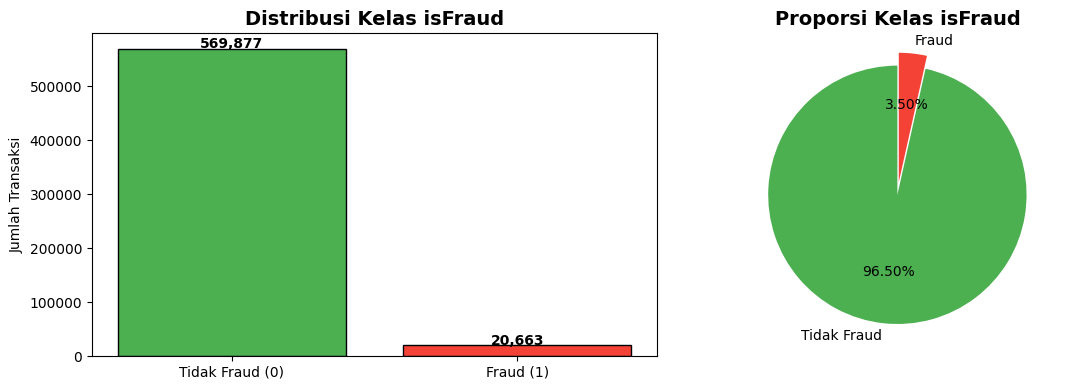

💡 Dataset sangat tidak seimbang (imbalanced) — akan ditangani dengan SMOTE


In [7]:
# =====================================================
# Analisis distribusi target: isFraud
# =====================================================
fraud_counts = df['isFraud'].value_counts()
fraud_pct = df['isFraud'].value_counts(normalize=True) * 100

print('=== Distribusi Label isFraud ===')
for label, cnt in fraud_counts.items():
    lbl_name = 'Fraud' if label == 1 else 'Tidak Fraud'
    print(f'  {lbl_name} ({label}): {cnt:,} ({fraud_pct[label]:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
axes[0].bar(['Tidak Fraud (0)', 'Fraud (1)'], fraud_counts.values,
            color=['#4CAF50', '#F44336'], edgecolor='black')
axes[0].set_title('Distribusi Kelas isFraud', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah Transaksi')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(fraud_counts.values, labels=['Tidak Fraud', 'Fraud'],
            autopct='%1.2f%%', colors=['#4CAF50', '#F44336'],
            startangle=90, explode=[0, 0.1])
axes[1].set_title('Proporsi Kelas isFraud', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_distribusi_kelas.png', dpi=100, bbox_inches='tight')
plt.show()
print('💡 Dataset sangat tidak seimbang (imbalanced) — akan ditangani dengan SMOTE')

Kolom dengan missing values: 374 dari 394 kolom
       Jumlah Missing  Persentase (%)
dist2          552913       93.628374
D7             551623       93.409930
D13            528588       89.509263
D14            528353       89.469469
D12            525823       89.041047
D6             517353       87.606767
D9             515614       87.312290
D8             515614       87.312290
V157           508595       86.123717
V163           508595       86.123717
V162           508595       86.123717
V161           508595       86.123717
V158           508595       86.123717
V153           508595       86.123717
V138           508595       86.123717
V155           508595       86.123717
V154           508595       86.123717
V149           508595       86.123717
V148           508595       86.123717
V147           508595       86.123717


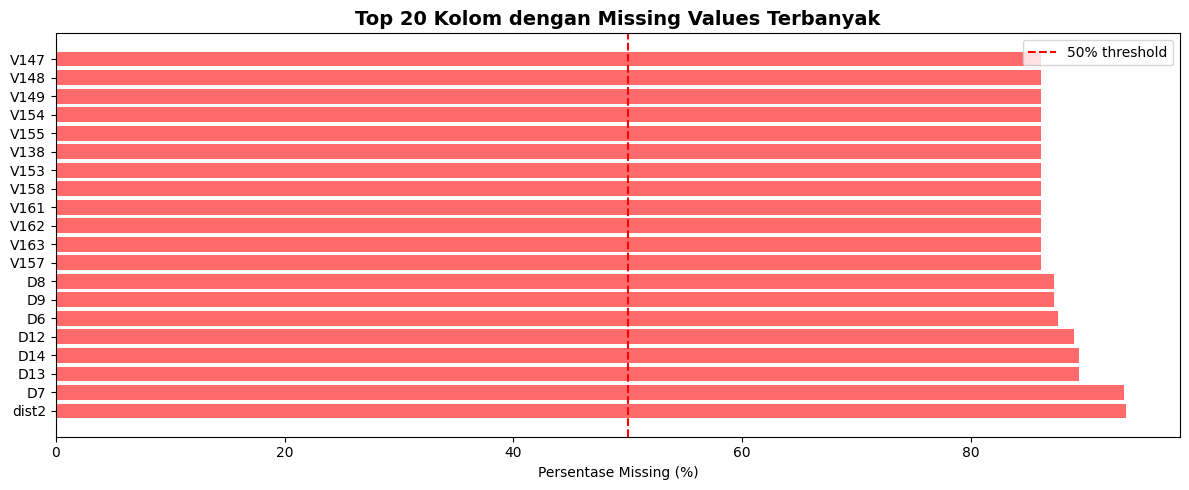

In [8]:
# =====================================================
# Analisis Missing Values
# =====================================================
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
}).query('`Jumlah Missing` > 0').sort_values('Persentase (%)', ascending=False)

print(f'Kolom dengan missing values: {len(missing_df)} dari {df.shape[1]} kolom')
print(missing_df.head(20))

# Plot top 20 kolom dengan missing values terbanyak
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    top_missing = missing_df.head(20)
    ax.barh(top_missing.index, top_missing['Persentase (%)'], color='#FF6B6B')
    ax.set_xlabel('Persentase Missing (%)')
    ax.set_title('Top 20 Kolom dengan Missing Values Terbanyak', fontsize=14, fontweight='bold')
    ax.axvline(x=50, color='red', linestyle='--', label='50% threshold')
    ax.legend()
    plt.tight_layout()
    plt.savefig('plot_missing_values.png', dpi=100, bbox_inches='tight')
    plt.show()

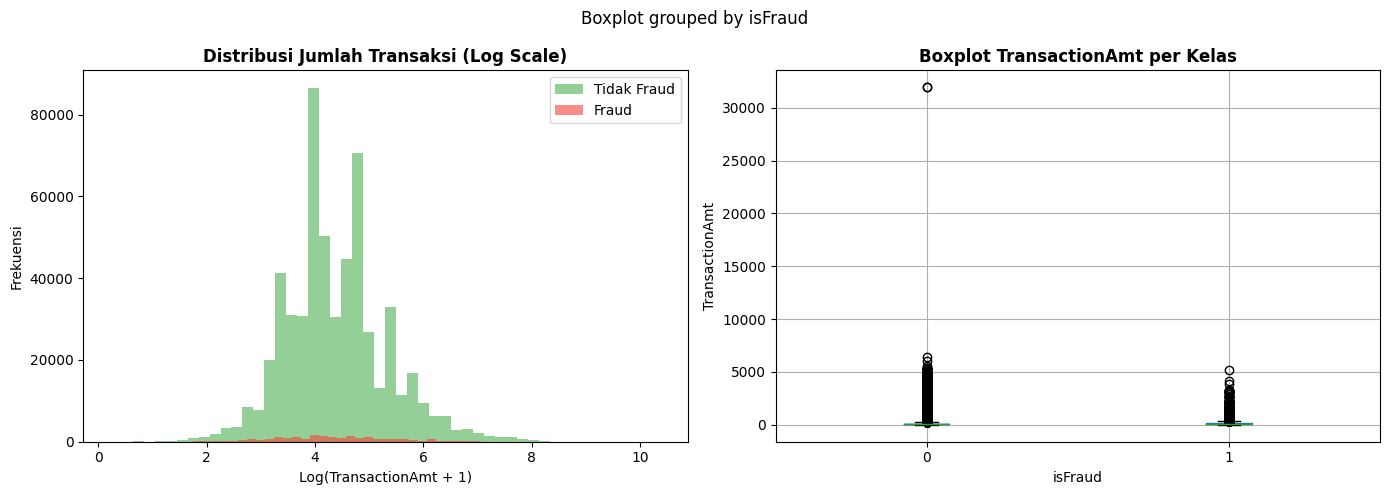

In [9]:
# =====================================================
# Distribusi TransactionAmt berdasarkan isFraud
# =====================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log transform untuk visualisasi yang lebih baik
for label, color, name in [(0, '#4CAF50', 'Tidak Fraud'), (1, '#F44336', 'Fraud')]:
    subset = df[df['isFraud'] == label]['TransactionAmt']
    axes[0].hist(np.log1p(subset), bins=50, alpha=0.6, color=color, label=name)

axes[0].set_xlabel('Log(TransactionAmt + 1)')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi Jumlah Transaksi (Log Scale)', fontsize=12, fontweight='bold')
axes[0].legend()

# Box plot
df.boxplot(column='TransactionAmt', by='isFraud', ax=axes[1])
axes[1].set_title('Boxplot TransactionAmt per Kelas', fontsize=12, fontweight='bold')
axes[1].set_xlabel('isFraud')
axes[1].set_ylabel('TransactionAmt')

plt.tight_layout()
plt.savefig('plot_transaction_dist.png', dpi=100, bbox_inches='tight')
plt.show()

## 🛠️ 4. Preprocessing Data

In [10]:
# =====================================================
# 4.1 Hapus kolom dengan missing values > 50%
# =====================================================
threshold = 0.5
missing_ratio = df.isnull().sum() / len(df)
cols_to_drop = missing_ratio[missing_ratio > threshold].index.tolist()

print(f'Kolom yang dihapus (missing > 50%): {len(cols_to_drop)}')
print(cols_to_drop[:10], '...' if len(cols_to_drop) > 10 else '')

df_clean = df.drop(columns=cols_to_drop)
print(f'\nShape setelah hapus kolom: {df_clean.shape}')

Kolom yang dihapus (missing > 50%): 174
['dist1', 'dist2', 'R_emaildomain', 'D5', 'D6', 'D7', 'D8', 'D9', 'D12', 'D13'] ...

Shape setelah hapus kolom: (590540, 220)


In [11]:
# =====================================================
# 4.2 Pisahkan fitur dan target
# =====================================================
TARGET = 'isFraud'

# Hapus TransactionID jika ada (bukan fitur prediktif)
if 'TransactionID' in df_clean.columns:
    df_clean = df_clean.drop(columns=['TransactionID'])

X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

print(f'Fitur (X): {X.shape}')
print(f'Target (y): {y.shape}')
print(f'Distribusi target: {dict(y.value_counts())}')

Fitur (X): (590540, 218)
Target (y): (590540,)
Distribusi target: {0: 569877, 1: 20663}


In [12]:
# =====================================================
# 4.3 Identifikasi kolom numerik dan kategorikal
# =====================================================
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f'Kolom kategorikal ({len(cat_cols)}): {cat_cols}')
print(f'Kolom numerik ({len(num_cols)}): {num_cols[:10]}...')

Kolom kategorikal (9): ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M6']
Kolom numerik (209): ['TransactionDT', 'TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'C1', 'C2']...


In [13]:
# =====================================================
# 4.4 Label Encoding untuk kolom kategorikal
# =====================================================
le = LabelEncoder()
for col in cat_cols:
    # Fill NaN dengan string 'missing' sebelum encoding
    X[col] = X[col].fillna('missing')
    X[col] = le.fit_transform(X[col].astype(str))

print(f'✅ Label Encoding selesai untuk {len(cat_cols)} kolom kategorikal')

✅ Label Encoding selesai untuk 9 kolom kategorikal


In [14]:
# =====================================================
# 4.5 Imputasi missing values untuk kolom numerik
# =====================================================
for col in num_cols:
    if X[col].isnull().sum() > 0:
        X[col] = X[col].fillna(X[col].median())

print(f'✅ Imputasi median selesai untuk kolom numerik')
print(f'Sisa missing values: {X.isnull().sum().sum()}')

✅ Imputasi median selesai untuk kolom numerik
Sisa missing values: 0


In [15]:
# =====================================================
# 4.6 Feature Engineering: Log Transform untuk TransactionAmt
# =====================================================
if 'TransactionAmt' in X.columns:
    X['TransactionAmt_log'] = np.log1p(X['TransactionAmt'])
    print('✅ Feature baru ditambahkan: TransactionAmt_log')

print(f'Total fitur setelah engineering: {X.shape[1]}')

✅ Feature baru ditambahkan: TransactionAmt_log
Total fitur setelah engineering: 219


In [16]:
# =====================================================
# 4.7 Split data: Train / Validation / Test
# =====================================================
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15, random_state=42, stratify=y_temp
)

print(f'Train set   : {X_train.shape[0]:,} baris ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Val set     : {X_val.shape[0]:,} baris ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test set    : {X_test.shape[0]:,} baris ({X_test.shape[0]/len(X)*100:.1f}%)')

Train set   : 426,665 baris (72.2%)
Val set     : 75,294 baris (12.8%)
Test set    : 88,581 baris (15.0%)


In [17]:
# =====================================================
# 4.8 Normalisasi Fitur (StandardScaler)
# =====================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print('✅ Normalisasi selesai (StandardScaler fit pada train set saja)')

✅ Normalisasi selesai (StandardScaler fit pada train set saja)


In [19]:
# =====================================================
# 4.9 Penanganan Class Imbalance dengan SMOTE
# =====================================================
print('Distribusi sebelum SMOTE:')
print(dict(pd.Series(y_train).value_counts()))

# Batasi sampling_strategy agar tidak terlalu besar (komputasi lebih efisien)
smote = SMOTE(random_state=42, sampling_strategy=0.3)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print('\nDistribusi sesudah SMOTE:')
print(dict(pd.Series(y_train_res).value_counts()))
print(f'\n✅ SMOTE selesai. Train shape baru: {X_train_res.shape}')

Distribusi sebelum SMOTE:
{0: 411736, 1: 14929}

Distribusi sesudah SMOTE:
{0: 411736, 1: 123520}

✅ SMOTE selesai. Train shape baru: (535256, 219)


## 🧠 5. Pembangunan Model Deep Learning

Arsitektur: **Multi-Layer Perceptron (MLP)**  
- Input Layer → Dense Layers → Batch Normalization → Dropout → Output Layer
- Aktivasi: ReLU (hidden), Sigmoid (output)
- Loss: Binary Crossentropy
- Optimizer: Adam

In [20]:
def build_model(input_dim, units_1=256, units_2=128, units_3=64,
                dropout_1=0.3, dropout_2=0.3, learning_rate=1e-3):
    """
    Membangun model MLP untuk klasifikasi biner (fraud detection).
    
    Parameter:
    - input_dim    : jumlah fitur input
    - units_*      : jumlah neuron pada tiap hidden layer
    - dropout_*    : dropout rate untuk regularisasi
    - learning_rate: learning rate optimizer Adam
    """
    model = keras.Sequential([
        # Input
        layers.Input(shape=(input_dim,)),
        
        # Hidden Layer 1
        layers.Dense(units_1, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_1),
        
        # Hidden Layer 2
        layers.Dense(units_2, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_2),
        
        # Hidden Layer 3
        layers.Dense(units_3, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        
        # Output (probabilitas fraud)
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall')
        ]
    )
    return model

# Tampilkan arsitektur model dasar
model_demo = build_model(X_train_res.shape[1])
model_demo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        56,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,329 (388.00 KB)

 Trainable params: 98,433 (384.50 KB)

 Non-trainable params: 896 (3.50 KB)

## ⚙️ 6. Hyperparameter Tuning dengan Optuna

Optuna menggunakan algoritma **TPE (Tree-structured Parzen Estimator)** untuk mencari kombinasi hyperparameter terbaik secara efisien.

In [21]:
INPUT_DIM = X_train_res.shape[1]

def objective(trial):
    """
    Fungsi objektif Optuna:
    - Mencoba berbagai kombinasi hyperparameter
    - Melatih model dengan kombinasi tersebut
    - Mengembalikan nilai AUC pada validation set
    """
    # Ruang pencarian hyperparameter
    units_1 = trial.suggest_categorical('units_1', [64, 128, 256, 512])
    units_2 = trial.suggest_categorical('units_2', [32, 64, 128, 256])
    units_3 = trial.suggest_categorical('units_3', [16, 32, 64, 128])
    dropout_1 = trial.suggest_float('dropout_1', 0.1, 0.5)
    dropout_2 = trial.suggest_float('dropout_2', 0.1, 0.5)
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [256, 512, 1024])
    
    # Build & train model
    model = build_model(
        input_dim=INPUT_DIM,
        units_1=units_1, units_2=units_2, units_3=units_3,
        dropout_1=dropout_1, dropout_2=dropout_2,
        learning_rate=lr
    )
    
    early_stop = callbacks.EarlyStopping(
        monitor='val_auc', patience=3, restore_best_weights=True, mode='max'
    )
    
    history = model.fit(
        X_train_res, y_train_res,
        validation_data=(X_val_scaled, y_val),
        epochs=20,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )
    
    # Ambil nilai AUC terbaik pada validation set
    best_auc = max(history.history['val_auc'])
    return best_auc

# Jalankan Optuna study
print('⏳ Memulai Optuna hyperparameter tuning...')
print('   (Proses ini mungkin membutuhkan beberapa menit)')

study = optuna.create_study(
    direction='maximize',
    study_name='fraud_detection_mlp',
    sampler=TPESampler(seed=42)
)
study.optimize(objective, n_trials=15, show_progress_bar=True)

print(f'\n✅ Optuna selesai!')
print(f'   Best AUC       : {study.best_value:.4f}')
print(f'   Best params    : {study.best_params}')

⏳ Memulai Optuna hyperparameter tuning...
   (Proses ini mungkin membutuhkan beberapa menit)


Best trial: 2. Best value: 0.923368:  53%|█████▎    | 8/15 [13:39<11:57, 102.49s/it]

[W 2026-06-19 09:54:09,019] Trial 8 failed with parameters: {'units_1': 256, 'units_2': 128, 'units_3': 64, 'dropout_1': 0.3688542189623515, 'dropout_2': 0.4046478461314871, 'learning_rate': 0.00029872741995638395, 'batch_size': 256} because of the following error: MemoryError((535256, 219), dtype('float32')).
Traceback (most recent call last):
  File "c:\Users\62812\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\62812\AppData\Local\Temp\ipykernel_25788\1669513869.py", line 31, in objective
    history = model.fit(
              ^^^^^^^^^^
  File "c:\Users\62812\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\utils\traceback_utils.py", line 122, in error_handler
    raise e.with_traceback(filtered_tb) from None
  File "c:\Users\62812\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\python\framework\co

MemoryError: Unable to allocate 447. MiB for an array with shape (535256, 219) and data type float32

In [ ]:
# =====================================================
# Visualisasi hasil Optuna
# =====================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot history nilai objective per trial
trial_values = [t.value for t in study.trials if t.value is not None]
axes[0].plot(trial_values, marker='o', color='#2196F3', linewidth=2)
axes[0].axhline(y=study.best_value, color='red', linestyle='--', label=f'Best: {study.best_value:.4f}')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Validation AUC')
axes[0].set_title('Optuna: AUC per Trial', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot importansi hyperparameter
try:
    importance = optuna.importance.get_param_importances(study)
    params = list(importance.keys())
    values = list(importance.values())
    axes[1].barh(params, values, color='#FF9800')
    axes[1].set_xlabel('Importance')
    axes[1].set_title('Kepentingan Hyperparameter', fontsize=13, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
except:
    axes[1].text(0.5, 0.5, 'Tidak dapat menghitung\nimportance', 
                 ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig('plot_optuna_results.png', dpi=100, bbox_inches='tight')
plt.show()

In [23]:
import gc
import tensorflow as tf

# =====================================================
# FIX: Lanjutkan Optuna dengan proteksi MemoryError
# =====================================================

def objective_fixed(trial):
    # Bersihkan session Keras & garbage collect di tiap trial
    tf.keras.backend.clear_session()
    gc.collect()
    
    # Ruang pencarian (batch_size min 512 agar tidak OOM)
    units_1 = trial.suggest_categorical('units_1', [64, 128, 256, 512])
    units_2 = trial.suggest_categorical('units_2', [32, 64, 128, 256])
    units_3 = trial.suggest_categorical('units_3', [16, 32, 64, 128])
    dropout_1 = trial.suggest_float('dropout_1', 0.1, 0.5)
    dropout_2 = trial.suggest_float('dropout_2', 0.1, 0.5)
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [512, 1024, 2048])  # ← hapus 256
    
    model = build_model(
        input_dim=INPUT_DIM,
        units_1=units_1, units_2=units_2, units_3=units_3,
        dropout_1=dropout_1, dropout_2=dropout_2,
        learning_rate=lr
    )
    
    early_stop = callbacks.EarlyStopping(
        monitor='val_auc', patience=3, restore_best_weights=True, mode='max'
    )
    
    history = model.fit(
        X_train_res, y_train_res,
        validation_data=(X_val_scaled, y_val),
        epochs=20,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )
    
    tf.keras.backend.clear_session()  # bersihkan setelah trial selesai
    gc.collect()
    
    best_auc = max(history.history['val_auc'])
    return best_auc

# Lanjutkan study yang sudah ada (tidak reset dari 0!)
# catch=(Exception,) agar MemoryError tidak crash total
print(f'Trial berhasil sebelumnya: {len(study.trials)}')
print(f'Best AUC sejauh ini: {study.best_value:.4f}')
print('⏳ Melanjutkan tuning...')

study.optimize(
    objective_fixed,
    n_trials=10,                    # sisa trial (15 - ~7 yang sudah jalan)
    catch=(Exception,),             # ← tangkap MemoryError, skip trial, lanjut
    show_progress_bar=True
)

print(f'\n✅ Optuna selesai!')
print(f'   Total trials   : {len(study.trials)}')
print(f'   Best AUC       : {study.best_value:.4f}')
print(f'   Best params    : {study.best_params}')
    


Trial berhasil sebelumnya: 9
Best AUC sejauh ini: 0.9234
⏳ Melanjutkan tuning...


  0%|          | 0/10 [00:00<?, ?it/s]

Best trial: 2. Best value: 0.923368:  10%|█         | 1/10 [00:01<00:09,  1.07s/it]

[W 2026-06-19 09:56:19,328] Trial 9 failed with parameters: {'units_1': 512, 'units_2': 256, 'units_3': 16, 'dropout_1': 0.35806911616378, 'dropout_2': 0.16974657160199658, 'learning_rate': 0.002409214543666477} because of the following error: ValueError('CategoricalDistribution does not support dynamic value space.').
Traceback (most recent call last):
  File "c:\Users\62812\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\62812\AppData\Local\Temp\ipykernel_25788\2947418419.py", line 20, in objective_fixed
    batch_size = trial.suggest_categorical('batch_size', [512, 1024, 2048])  # ← hapus 256
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\62812\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\trial\_trial.py", line 414, in suggest_categorical
    return self._suggest(name, Cate

Best trial: 2. Best value: 0.923368:  20%|██        | 2/10 [00:01<00:06,  1.18it/s]

...

[W 2026-06-19 09:56:24,063] Trial 16 failed with parameters: {'units_1': 128, 'units_2': 32, 'units_3': 16, 'dropout_1': 0.12067268846744308, 'dropout_2': 0.3125418526272592, 'learning_rate': 0.0012057860169848358} because of the following error: ValueError('CategoricalDistribution does not support dynamic value space.').
Traceback (most recent call last):
  File "c:\Users\62812\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\62812\AppData\Local\Temp\ipykernel_25788\2947418419.py", line 20, in objective_fixed
    batch_size = trial.suggest_categorical('batch_size', [512, 1024, 2048])  # ← hapus 256
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\62812\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\trial\_trial.py", line 414, in suggest_categorical
    return self._suggest(name, C

Best trial: 2. Best value: 0.923368:  90%|█████████ | 9/10 [00:06<00:00,  1.47it/s]

[W 2026-06-19 09:56:24,736] Trial 17 failed with parameters: {'units_1': 256, 'units_2': 256, 'units_3': 16, 'dropout_1': 0.1625748170684344, 'dropout_2': 0.20009715926583815, 'learning_rate': 0.001254449923662645} because of the following error: ValueError('CategoricalDistribution does not support dynamic value space.').
Traceback (most recent call last):
  File "c:\Users\62812\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\62812\AppData\Local\Temp\ipykernel_25788\2947418419.py", line 20, in objective_fixed
    batch_size = trial.suggest_categorical('batch_size', [512, 1024, 2048])  # ← hapus 256
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\62812\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\trial\_trial.py", line 414, in suggest_categorical
    return self._suggest(name, C

Best trial: 2. Best value: 0.923368: 100%|██████████| 10/10 [00:07<00:00,  1.39it/s]

[W 2026-06-19 09:56:25,431] Trial 18 failed with parameters: {'units_1': 64, 'units_2': 256, 'units_3': 32, 'dropout_1': 0.44218423360440295, 'dropout_2': 0.3814631437520095, 'learning_rate': 0.0008878664758716851} because of the following error: ValueError('CategoricalDistribution does not support dynamic value space.').
Traceback (most recent call last):
  File "c:\Users\62812\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\62812\AppData\Local\Temp\ipykernel_25788\2947418419.py", line 20, in objective_fixed
    batch_size = trial.suggest_categorical('batch_size', [512, 1024, 2048])  # ← hapus 256
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\62812\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\trial\_trial.py", line 414, in suggest_categorical
    return self._suggest(name, C

## 🏋️ 7. Training Model Final dengan Best Hyperparameters

Gunakan hyperparameter terbaik dari Optuna untuk melatih model final.

In [25]:
import os

# =====================================================
# Setup MLFlow Tracking (SQLite backend)
# =====================================================
mlflow.set_tracking_uri('sqlite:///mlflow.db')  # simpan sebagai file mlflow.db
mlflow.set_experiment('Fraud_Detection_Task1')

best_params = study.best_params
print('🚀 Memulai training model final...')
print(f'Hyperparameter terbaik: {best_params}')
print('✅ MLFlow backend: SQLite (mlflow.db)')


2026/06/19 09:57:58 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/19 09:57:58 INFO mlflow.store.db.utils: Updating database tables
2026/06/19 09:58:00 INFO mlflow.tracking.fluent: Experiment with name 'Fraud_Detection_Task1' does not exist. Creating a new experiment.


🚀 Memulai training model final...
Hyperparameter terbaik: {'units_1': 256, 'units_2': 256, 'units_3': 32, 'dropout_1': 0.31868411173731187, 'dropout_2': 0.17394178221021084, 'learning_rate': 0.00869299151113955, 'batch_size': 512}
✅ MLFlow backend: SQLite (mlflow.db)


In [26]:
with mlflow.start_run(run_name='best_model_fraud_detection') as run:
    
    # Log semua hyperparameter terbaik ke MLFlow
    mlflow.log_params(best_params)
    mlflow.log_param('smote_ratio', 0.3)
    mlflow.log_param('scaler', 'StandardScaler')
    mlflow.log_param('architecture', 'MLP_3Layer_BN_Dropout')
    mlflow.log_param('n_features', X_train_res.shape[1])
    mlflow.log_param('train_samples', X_train_res.shape[0])
    
    # Build model dengan hyperparameter terbaik
    final_model = build_model(
        input_dim=X_train_res.shape[1],
        units_1=best_params.get('units_1', 256),
        units_2=best_params.get('units_2', 128),
        units_3=best_params.get('units_3', 64),
        dropout_1=best_params.get('dropout_1', 0.3),
        dropout_2=best_params.get('dropout_2', 0.3),
        learning_rate=best_params.get('learning_rate', 1e-3)
    )
    
    batch_size = best_params.get('batch_size', 512)
    
    # Callbacks
    early_stop = callbacks.EarlyStopping(
        monitor='val_auc', patience=5, restore_best_weights=True, mode='max'
    )
    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
    )
    
    # Training
    history = final_model.fit(
        X_train_res, y_train_res,
        validation_data=(X_val_scaled, y_val),
        epochs=50,
        batch_size=batch_size,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )
    
    # Prediksi pada test set
    y_pred_proba = final_model.predict(X_test_scaled, verbose=0).ravel()
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    # Hitung metrik evaluasi
    auc_score = roc_auc_score(y_test, y_pred_proba)
    f1 = f1_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    print(f'\n📊 Hasil Evaluasi pada Test Set:')
    print(f'   AUC-ROC   : {auc_score:.4f}')
    print(f'   F1-Score  : {f1:.4f}')
    print(f'   Precision : {precision:.4f}')
    print(f'   Recall    : {recall:.4f}')
    
    # Log metrik ke MLFlow
    mlflow.log_metric('test_auc', auc_score)
    mlflow.log_metric('test_f1', f1)
    mlflow.log_metric('test_precision', precision)
    mlflow.log_metric('test_recall', recall)
    
    # Log training history
    for epoch, (loss, auc) in enumerate(zip(
        history.history['loss'], history.history['auc']
    )):
        mlflow.log_metric('train_loss', loss, step=epoch)
        mlflow.log_metric('train_auc', auc, step=epoch)
    
    # Simpan model ke MLFlow
    mlflow.keras.log_model(final_model, 'fraud_detection_model')
    
    # Simpan plot ke MLFlow
    for plot_file in ['plot_distribusi_kelas.png', 'plot_missing_values.png',
                      'plot_transaction_dist.png', 'plot_optuna_results.png']:
        if os.path.exists(plot_file):
            mlflow.log_artifact(plot_file)
    
    run_id = run.info.run_id

print(f'\n✅ MLFlow tracking selesai!')
print(f'   Run ID: {run_id}')
print(f'   Jalankan: mlflow ui  — untuk melihat dashboard')

Epoch 1/50
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - auc: 0.8795 - loss: 0.3402 - precision: 0.7667 - recall: 0.5441 - val_auc: 0.8864 - val_loss: 0.1548 - val_precision: 0.3911 - val_recall: 0.5423 - learning_rate: 0.0087
Epoch 2/50
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - auc: 0.9189 - loss: 0.2828 - precision: 0.8160 - recall: 0.6402 - val_auc: 0.8973 - val_loss: 0.1214 - val_precision: 0.4991 - val_recall: 0.5340 - learning_rate: 0.0087
Epoch 3/50
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - auc: 0.9346 - loss: 0.2555 - precision: 0.8357 - recall: 0.6832 - val_auc: 0.9073 - val_loss: 0.1190 - val_precision: 0.5167 - val_recall: 0.5708 - learning_rate: 0.0087
Epoch 4/50
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - auc: 0.9438 - loss: 0.2376 - precision: 0.8489 - recall: 0.7096 - val_auc: 0.9158 - val_loss: 0.1116 - val_precision: 0.5480 - val_recall: 0.5738 - learning_rate: 0.0087
Epoch 5/50
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - auc: 0.9505 - loss: 0.2242 - precision:

2026/06/19 10:00:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/19 10:00:09 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.



✅ MLFlow tracking selesai!
   Run ID: 8cf4380e38fc40df985d18a94fdb72d4
   Jalankan: mlflow ui  — untuk melihat dashboard


## 📊 8. Evaluasi Model

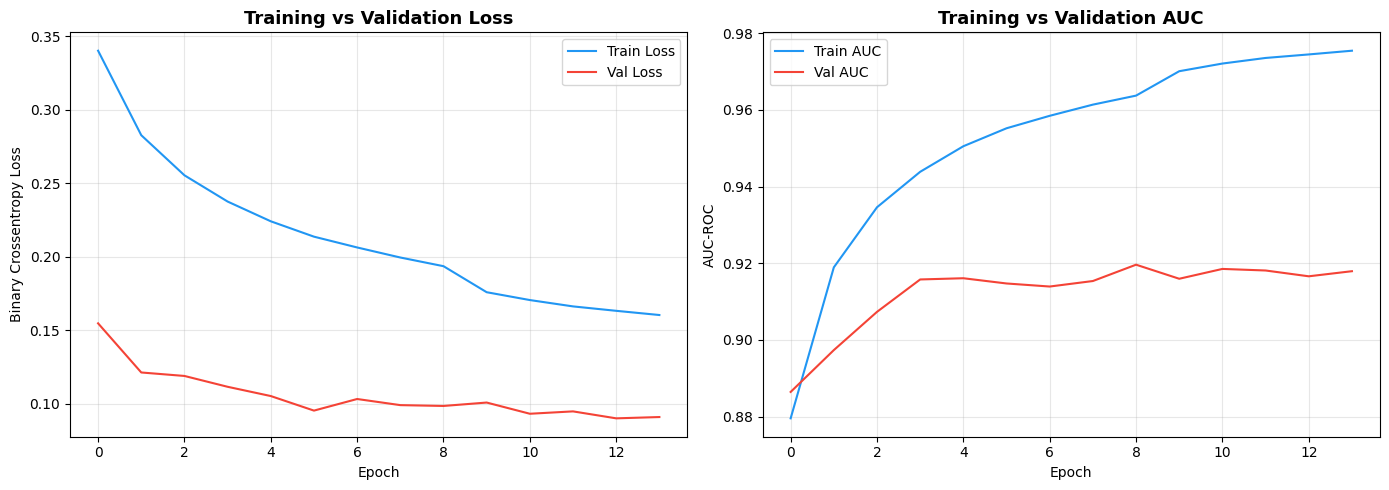

In [27]:
# =====================================================
# 8.1 Training History
# =====================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss
axes[0].plot(history.history['loss'], label='Train Loss', color='#2196F3')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='#F44336')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy Loss')
axes[0].set_title('Training vs Validation Loss', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot AUC
axes[1].plot(history.history['auc'], label='Train AUC', color='#2196F3')
axes[1].plot(history.history['val_auc'], label='Val AUC', color='#F44336')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('Training vs Validation AUC', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plot_training_history.png', dpi=100, bbox_inches='tight')
plt.show()

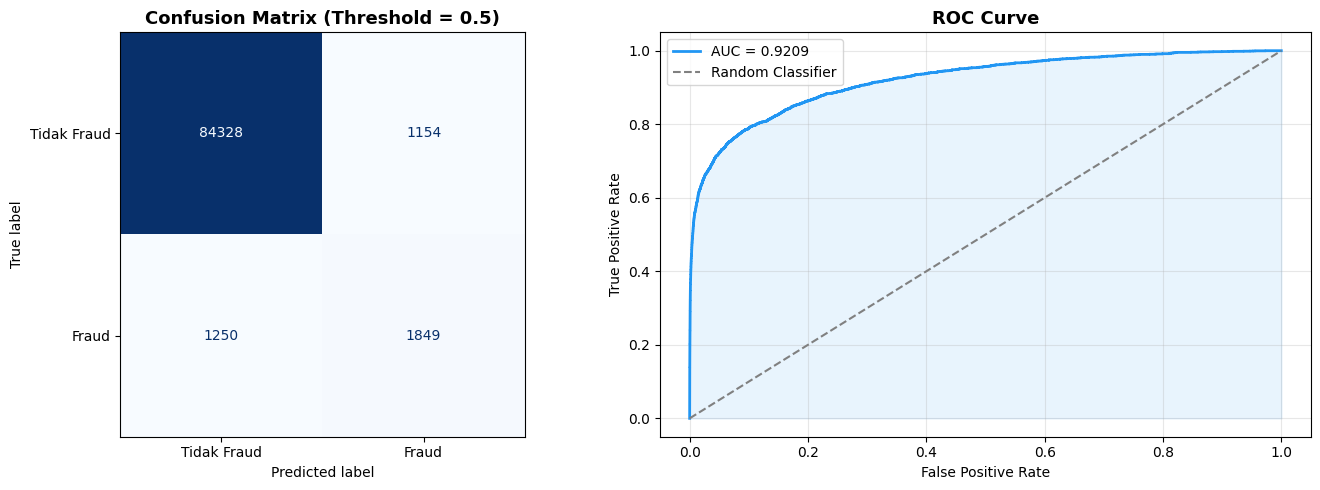

In [28]:
# =====================================================
# 8.2 Confusion Matrix
# =====================================================
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Tidak Fraud', 'Fraud'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Threshold = 0.5)', fontsize=13, fontweight='bold')

# ROC Curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#2196F3', lw=2, label=f'AUC = {auc_score:.4f}')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2196F3')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plot_confusion_roc.png', dpi=100, bbox_inches='tight')
plt.show()

In [29]:
# =====================================================
# 8.3 Classification Report Lengkap
# =====================================================
print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Tidak Fraud', 'Fraud']))

print('=== Ringkasan Metrik ===')
metrics_summary = pd.DataFrame({
    'Metrik': ['AUC-ROC', 'F1-Score', 'Precision', 'Recall'],
    'Nilai': [auc_score, f1, precision, recall]
})
metrics_summary['Nilai'] = metrics_summary['Nilai'].round(4)
print(metrics_summary.to_string(index=False))

=== Classification Report ===
              precision    recall  f1-score   support

 Tidak Fraud       0.99      0.99      0.99     85482
       Fraud       0.62      0.60      0.61      3099

    accuracy                           0.97     88581
   macro avg       0.80      0.79      0.80     88581
weighted avg       0.97      0.97      0.97     88581

=== Ringkasan Metrik ===
   Metrik  Nilai
  AUC-ROC 0.9209
 F1-Score 0.6060
Precision 0.6157
   Recall 0.5966


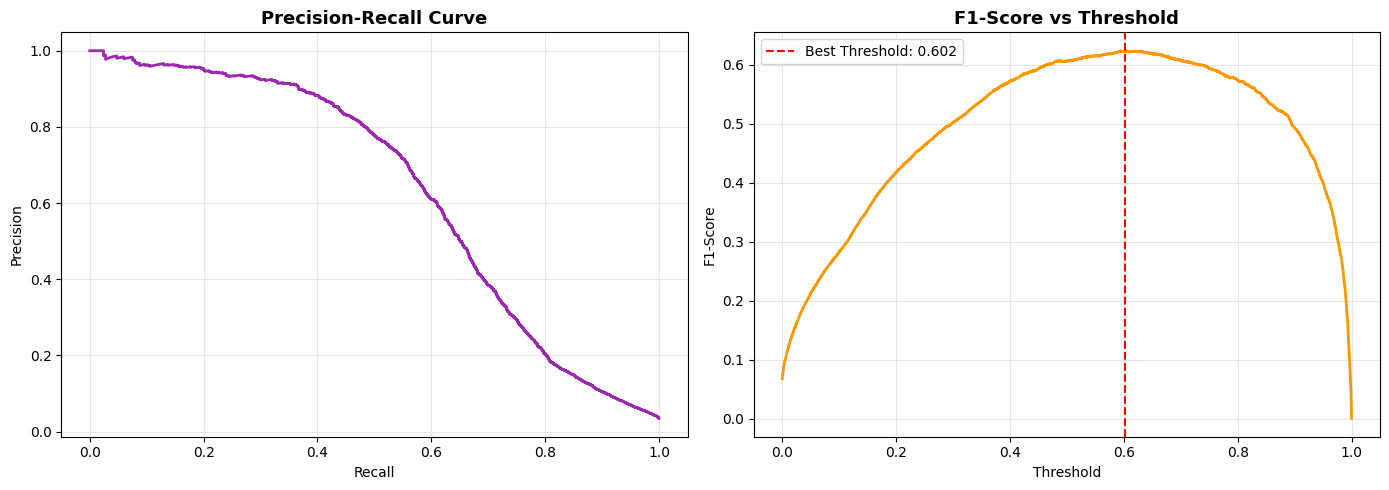


Threshold optimal berdasarkan F1-Score: 0.6024
F1-Score dengan threshold optimal: 0.6236
              precision    recall  f1-score   support

 Tidak Fraud       0.98      0.99      0.99     85482
       Fraud       0.71      0.55      0.62      3099

    accuracy                           0.98     88581
   macro avg       0.85      0.77      0.81     88581
weighted avg       0.97      0.98      0.98     88581



In [30]:
# =====================================================
# 8.4 Analisis Threshold Optimal
# =====================================================
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresh = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_thresh_idx = np.argmax(f1_scores)
best_threshold = thresh[best_thresh_idx] if best_thresh_idx < len(thresh) else 0.5

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision-Recall Curve
axes[0].plot(recalls, precisions, color='#9C27B0', lw=2)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# F1 vs Threshold
axes[1].plot(thresh, f1_scores[:-1], color='#FF9800', lw=2)
axes[1].axvline(x=best_threshold, color='red', linestyle='--',
               label=f'Best Threshold: {best_threshold:.3f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1-Score')
axes[1].set_title('F1-Score vs Threshold', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plot_threshold_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'\nThreshold optimal berdasarkan F1-Score: {best_threshold:.4f}')

# Evaluasi dengan threshold optimal
y_pred_optimal = (y_pred_proba >= best_threshold).astype(int)
f1_opt = f1_score(y_test, y_pred_optimal)
print(f'F1-Score dengan threshold optimal: {f1_opt:.4f}')
print(classification_report(y_test, y_pred_optimal, target_names=['Tidak Fraud', 'Fraud']))

## 📈 9. MLFlow — Melihat Hasil Tracking

Untuk membuka dashboard MLFlow, jalankan perintah berikut di terminal:

```bash
mlflow ui
```

Kemudian buka browser dan akses: **http://localhost:5000**

In [31]:
# =====================================================
# Tampilkan ringkasan eksperimen MLFlow
# =====================================================
import mlflow
from mlflow.tracking import MlflowClient

client = MlflowClient()
experiment = client.get_experiment_by_name('Fraud_Detection_Task1')

if experiment:
    runs = client.search_runs(
        experiment_ids=[experiment.experiment_id],
        order_by=['metrics.test_auc DESC']
    )
    
    print('=== Ringkasan Eksperimen MLFlow ===')
    print(f'Experiment ID  : {experiment.experiment_id}')
    print(f'Jumlah runs    : {len(runs)}')
    
    if runs:
        best_run = runs[0]
        print(f'\nBest Run:')
        print(f'  Run ID  : {best_run.info.run_id}')
        print(f'  AUC     : {best_run.data.metrics.get("test_auc", "N/A"):.4f}')
        print(f'  F1      : {best_run.data.metrics.get("test_f1", "N/A"):.4f}')
        print(f'  Params  : {dict(list(best_run.data.params.items())[:5])} ...')
else:
    print('Eksperimen belum ditemukan. Pastikan MLFlow tracking sudah dijalankan.')

=== Ringkasan Eksperimen MLFlow ===
Experiment ID  : 1
Jumlah runs    : 1

Best Run:
  Run ID  : 8cf4380e38fc40df985d18a94fdb72d4
  AUC     : 0.9209
  F1      : 0.6060
  Params  : {'units_1': '256', 'units_2': '256', 'units_3': '32', 'dropout_1': '0.31868411173731187', 'dropout_2': '0.17394178221021084'} ...


## 🔚 10. Kesimpulan

### Ringkasan Pipeline

| Tahap | Metode yang Digunakan |
|-------|----------------------|
| Preprocessing | Hapus kolom missing >50%, Label Encoding, Median Imputation |
| Feature Engineering | Log transform TransactionAmt |
| Penanganan Imbalance | SMOTE (sampling_strategy=0.3) |
| Normalisasi | StandardScaler |
| Model | MLP 3 Layer + BatchNorm + Dropout |
| Tuning | Optuna TPE (15 trials) |
| Evaluasi | AUC-ROC, F1, Precision, Recall, Confusion Matrix |
| Tracking | MLFlow (lokal) |

In [ ]:
# =====================================================
# Ringkasan akhir
# =====================================================
print('=' * 55)
print('   RINGKASAN AKHIR — TASK 1: FRAUD DETECTION')
print('=' * 55)
print(f'Dataset          : train_transaction.csv')
print(f'Total fitur      : {X.shape[1]}')
print(f'Total sampel     : {X.shape[0]:,}')
print(f'Class ratio      : {dict(y.value_counts())}')
print(f'Model            : MLP 3-Layer (Keras)')
print(f'Optuna trials    : 15')
print(f'Best Optuna AUC  : {study.best_value:.4f}')
print(f'-' * 55)
print(f'TEST SET RESULTS:')
print(f'  AUC-ROC        : {auc_score:.4f}')
print(f'  F1-Score       : {f1:.4f}')
print(f'  Precision      : {precision:.4f}')
print(f'  Recall         : {recall:.4f}')
print('=' * 55)

   RINGKASAN AKHIR — TASK 1: FRAUD DETECTION
Dataset          : train_transaction.csv
Total fitur      : 219
Total sampel     : 590,540
Class ratio      : {0: 569877, 1: 20663}
Model            : MLP 3-Layer (Keras)
Optuna trials    : 15
Best Optuna AUC  : 0.9234
-------------------------------------------------------
TEST SET RESULTS:
  AUC-ROC        : 0.9209
  F1-Score       : 0.6060
  Precision      : 0.6157
  Recall         : 0.5966


: 